# Mirror Optimization Notebook


## 1. Imports and Mitsuba variant

This first block imports the rendering and analysis libraries and sets the Mitsuba AD variants used for optimization.


In [1]:
import drjit as dr
import mitsuba as mi

mi.set_variant('cuda_ad_rgb', 'llvm_ad_rgb')

## 2. Integrator configuration

The projective PRB integrator is used for all subsequent renders and optimization methods.


In [2]:
integrator = {
    'type': 'prb_projective',
    'sppc': 32,
    'sppp': 256,
    'sppi': 1024,
}

## 3. Scene construction

This block builds the mirror scene: a reflective wall, a bunny mesh, and an environment light.

The scene geometry and lighting here are the canonical setup used by the original notebook.


In [3]:
from mitsuba.scalar_rgb import Transform4f as T

scene = mi.load_dict({
    'type': 'scene',
    'integrator': integrator,
    'sensor':  {
        'type': 'perspective',
        'to_world': T().look_at(
                        origin=(0, 0, -2.2+1.5),
                        target=(0, 0, -3.0),
                        up=(0, 1, 0)
                    ),
        'fov': 120,
        'film': {
            'type': 'hdrfilm',
            'width': 512,
            'height': 512,
            'rfilter': { 'type': 'gaussian' },
            'sample_border': True
        },
    },
    'wall': {
        'type': 'obj',
        # 'filename': '/home/haolin/Projects/vhc/codes/pose/scenes/meshes/sphere.obj',
        'filename': '/home/haolin/Projects/vhc/codes/pose/scenes/meshes/rectangle.obj',
        'to_world': T().translate([0, 0, -3.0+1.5]).scale(1.2),
        'face_normals': True,
        'bsdf': {
            'type': 'roughconductor',
            'material': 'Al',
            'alpha': 0.1
        }
    },
    'bunny': {
        'type': 'ply',
        'filename': '/home/haolin/Projects/vhc/codes/pose/scenes/meshes/bunny.ply',
        'to_world': T().translate([0.0, 0, 0]).scale(12),
        'bsdf': {
            'type': 'diffuse',
            'reflectance': { 'type': 'rgb', 'value': (0.3, 0.3, 0.75) },
        },
    },
    'light': {
        # envmap
        'type': 'envmap',
        'filename': '/home/haolin/Projects/vhc/codes/pose/scenes/textures/envmap.exr',
    },
})


## 4. Access differentiable scene parameters

We traverse the Mitsuba scene and extract the bunny vertex buffer so later cells can rewrite it when changing pose.


In [4]:
params = mi.traverse(scene)
initial_vertex_positions = dr.unravel(mi.Point3f, params['bunny.vertex_positions'])

## 5. Pose application helper

This helper applies the current optimizer pose to the bunny by transforming vertex positions in-place.


In [5]:
def apply_transformation(params, opt):
    # opt['trans'] = dr.clip(opt['trans'], -0.5, 0.5)
    # opt['angle'] = dr.clip(opt['angle'], -0.5, 0.5)
    
    trafo = mi.Transform4f().translate([opt['trans'].x, opt['trans'].y, 0.0]).rotate([0, 1, 0], opt['angle'] * 360.0)
    
    params['bunny.vertex_positions'] = dr.ravel(trafo @ initial_vertex_positions)
    params.update()

## 6. Render the target pose

This cell defines the target pose and renders the reference image used as the optimization target or fallback reference.


In [6]:
target = mi.ad.Adam(lr=0.025)
target['angle'] = mi.Float(0.0)
target['trans'] = mi.Point2f(1.2, 0.0)
apply_transformation(params, target)

img_ref = mi.render(scene, seed=0, spp=1024)

mi.util.convert_to_bitmap(img_ref).write('reference.png')
mi.util.convert_to_bitmap(img_ref)

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [512, 512],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 768 KiB of image data ]
]

## 7. Render the initial pose

This cell defines the starting pose for optimization and renders the initial image before any updates.


In [7]:
opt = mi.ad.Adam(lr=0.05)
opt['angle'] = mi.Float(0.5)
opt['trans'] = mi.Point2f(-0.8, 0.2)

apply_transformation(params, opt)

img_init = mi.render(scene, seed=0, spp=1024)

mi.util.convert_to_bitmap(img_init).write('initial.png')
mi.util.convert_to_bitmap(img_init)

Bitmap[
  pixel_format = rgb,
  component_format = uint8,
  size = [512, 512],
  srgb_gamma = 1,
  struct = Struct<3>[
    uint8 R; // @0, normalized, gamma, premultiplied alpha
    uint8 G; // @1, normalized, gamma, premultiplied alpha
    uint8 B; // @2, normalized, gamma, premultiplied alpha
  ],
  data = [ 768 KiB of image data ]
]

## 8. Shared iteration and sampling settings

These variables define the optimization loop length and the per-iteration samples-per-pixel budget used by the methods below.


In [8]:
iteration_count = 100
spp = 64

## 9. Shared helper utilities

These helpers support video scheduling, finite-difference optimization, LOIR, plotting, and other method-specific utilities.

This code is reused exactly from the original notebook.


In [9]:
from pathlib import Path
import imageio
import numpy as np
from PIL import Image, ImageFilter
from matplotlib import pyplot as plt


def srgb_to_linear_np(x):
    x = np.clip(x, 0.0, 1.0).astype(np.float32)
    return np.where(
        x <= 0.04045,
        x / 12.92,
        ((x + 0.055) / 1.055) ** 2.4,
    ).astype(np.float32)


class VideoFrameScheduler:
    def __init__(self, video_path, n_iter, fallback, resolution, video_ratio=0.8):
        self.frames = []
        self.fallback = fallback
        self.n_video_iters = int(n_iter * video_ratio)

        if video_path is None:
            return

        reader = imageio.get_reader(str(video_path))
        try:
            for frame in reader:
                rgb = frame[..., :3]
                if rgb.shape[0] != resolution or rgb.shape[1] != resolution:
                    rgb = np.array(
                        Image.fromarray(rgb).resize((resolution, resolution), Image.Resampling.BILINEAR)
                    )
                rgb = srgb_to_linear_np(rgb.astype(np.float32) / 255.0)
                self.frames.append(mi.TensorXf(rgb))
        finally:
            reader.close()

    def get_ref(self, iteration):
        if iteration >= self.n_video_iters or not self.frames:
            return self.fallback
        frac = iteration / max(self.n_video_iters - 1, 1)
        idx = min(int(round(frac * (len(self.frames) - 1))), len(self.frames) - 1)
        return self.frames[idx]


def clip_pose(angle, tx, ty):
    return (
        float(np.clip(angle, -0.5, 0.5)),
        float(np.clip(tx, -0.5, 0.5)),
        float(np.clip(ty, -0.5, 0.5)),
    )


def set_pose_values(angle, tx, ty):
    angle, tx, ty = clip_pose(angle, tx, ty)
    trafo = mi.Transform4f().translate([tx, ty, 0.0]).rotate([0, 1, 0], angle * 360.0)
    params['bunny.vertex_positions'] = dr.ravel(trafo @ initial_vertex_positions)
    params.update()
    return angle, tx, ty


def render_pose_tensor(angle, tx, ty, seed=0, spp=16):
    angle, tx, ty = set_pose_values(angle, tx, ty)
    img = mi.render(scene, params=params, seed=seed, spp=spp)
    return img, angle, tx, ty


def render_pose_np(angle, tx, ty, seed=0, spp=16):
    img, angle, tx, ty = render_pose_tensor(angle, tx, ty, seed=seed, spp=spp)
    return np.array(img, copy=True), angle, tx, ty


def grayscale_np(image):
    return (
        0.2126 * image[..., 0]
        + 0.7152 * image[..., 1]
        + 0.0722 * image[..., 2]
    ).astype(np.float32)


def loir_loss_np(pred, target, n_bins=16):
    pred_gray = grayscale_np(pred)
    target_gray = grayscale_np(target)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    total = 0.0

    for sigma in (0.0, 2.0, 5.0):
        if sigma > 0.0:
            pred_blur = np.asarray(
                Image.fromarray(np.uint8(np.clip(pred_gray * 255.0, 0, 255))).filter(ImageFilter.GaussianBlur(radius=sigma)),
                dtype=np.float32,
            ) / 255.0
            target_blur = np.asarray(
                Image.fromarray(np.uint8(np.clip(target_gray * 255.0, 0, 255))).filter(ImageFilter.GaussianBlur(radius=sigma)),
                dtype=np.float32,
            ) / 255.0
        else:
            pred_blur = pred_gray
            target_blur = target_gray

        pred_hist, _ = np.histogram(pred_blur, bins=bins, density=True)
        target_hist, _ = np.histogram(target_blur, bins=bins, density=True)
        pred_cdf = np.cumsum(pred_hist)
        target_cdf = np.cumsum(target_hist)
        total += float(np.mean(np.abs(pred_cdf - target_cdf)))

    return total / 3.0


def adam_update_vec(x, grad, state, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    state['t'] += 1
    state['m'] = beta1 * state['m'] + (1.0 - beta1) * grad
    state['v'] = beta2 * state['v'] + (1.0 - beta2) * (grad * grad)
    m_hat = state['m'] / (1.0 - beta1 ** state['t'])
    v_hat = state['v'] / (1.0 - beta2 ** state['t'])
    return x - lr * m_hat / (np.sqrt(v_hat) + eps)


def show_optimization_summary(loss_hist, final_img, ref_img, title_prefix):
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    axs[0][0].plot(loss_hist)
    axs[0][0].set_xlabel('iteration')
    axs[0][0].set_ylabel('Loss')
    axs[0][0].set_title(f'{title_prefix} loss plot')

    axs[0][1].imshow(mi.util.convert_to_bitmap(img_init))
    axs[0][1].axis('off')
    axs[0][1].set_title('Initial image')

    axs[1][0].imshow(mi.util.convert_to_bitmap(final_img))
    axs[1][0].axis('off')
    axs[1][0].set_title(f'{title_prefix} optimized image')

    axs[1][1].imshow(mi.util.convert_to_bitmap(ref_img))
    axs[1][1].axis('off')
    axs[1][1].set_title(f'{title_prefix} reference')

    plt.tight_layout()


def show_video_progress(snapshots, title_prefix, ncols=2):
    if not snapshots:
        return

    nrows = len(snapshots)
    fig, axs = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axs = np.atleast_2d(axs)

    for row, (iteration, render_img, ref_img) in enumerate(snapshots):
        axs[row][0].imshow(mi.util.convert_to_bitmap(render_img))
        axs[row][0].axis('off')
        axs[row][0].set_title(f'{title_prefix} render @ iter {iteration + 1}')

        axs[row][1].imshow(mi.util.convert_to_bitmap(ref_img))
        axs[row][1].axis('off')
        axs[row][1].set_title(f'{title_prefix} reference @ iter {iteration + 1}')

    plt.tight_layout()


img_ref_np = np.array(img_ref, copy=True)
resolution = int(scene.sensors()[0].film().crop_size()[0])


## 10. Method A: Video-guided optimization

This method uses differentiable rendering, but instead of always comparing against the final target image, it follows frames from a guidance video for the early part of optimization and then falls back to the target reference.


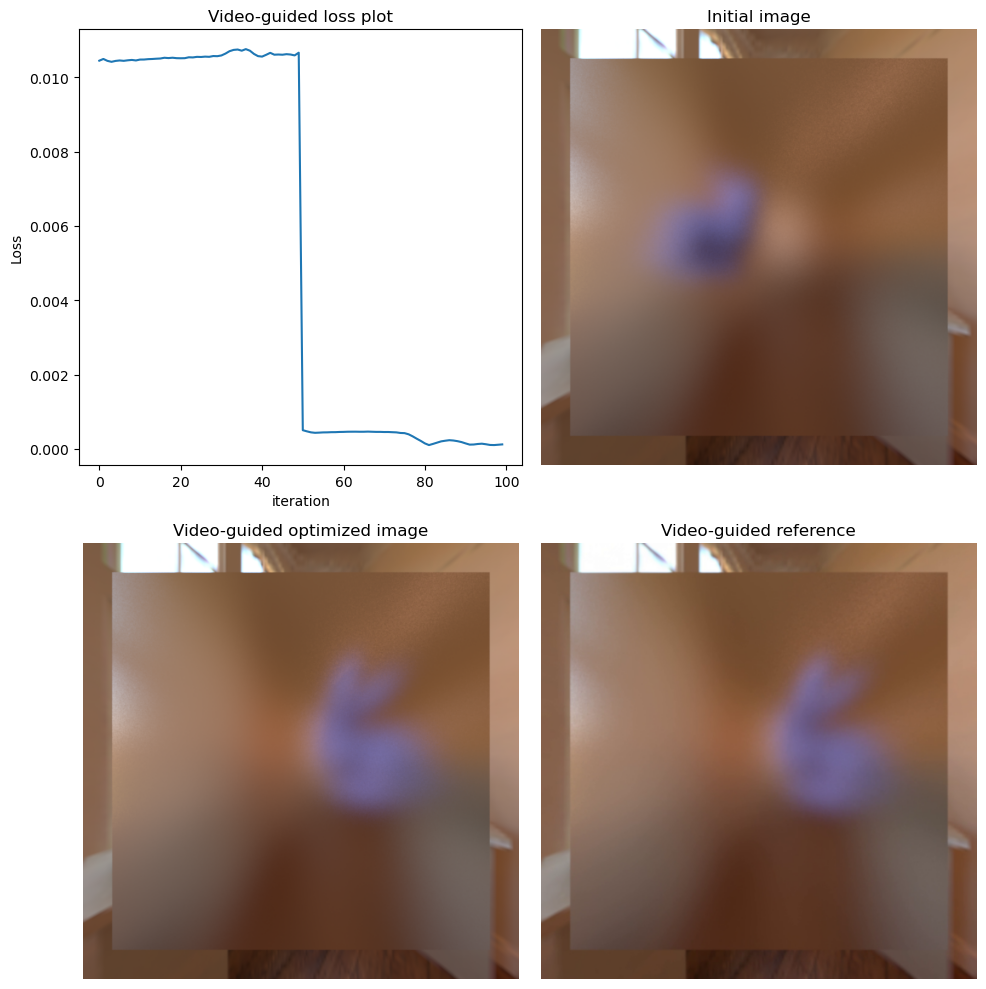

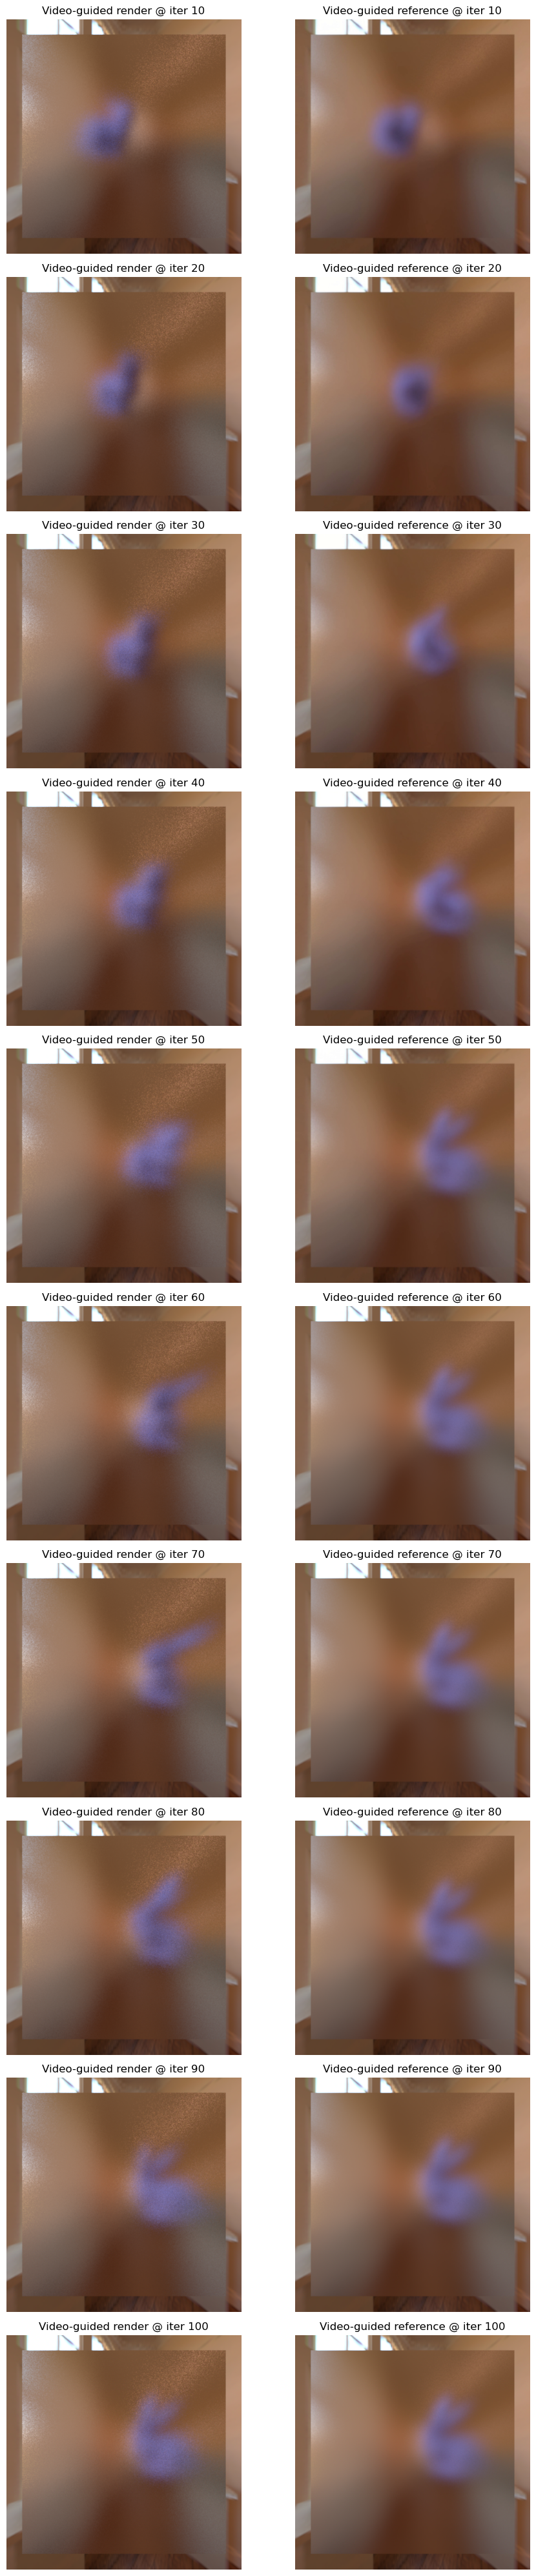

In [10]:
# re-initialize the parameters for video optimization

video_iteration_count = iteration_count
video_spp = spp
video_ratio = 0.5
video_path = Path('/home/haolin/Projects/vhc/codes/pose/scenes/mirror/videos/output.mp4')
video_opt = mi.ad.Adam(lr=0.05)
video_opt['angle'] = mi.Float(0.5)
video_opt['trans'] = mi.Point2f(-0.8, 0.2)
video_scheduler = VideoFrameScheduler(
    video_path=video_path,
    n_iter=video_iteration_count,
    fallback=img_ref,
    resolution=resolution,
    video_ratio=video_ratio,
)

video_loss_hist = []
video_ref_frames = []
video_snapshots = []

for it in range(video_iteration_count):
    apply_transformation(params, video_opt)
    img = mi.render(scene, params=params, seed=10000 + it, spp=video_spp)
    current_ref = video_scheduler.get_ref(it)
    loss = dr.sum(dr.square(img - current_ref)) / len(img.array)
    dr.backward(loss)
    video_opt.step()

    video_loss_hist.append(float(loss.array[0]))
    video_ref_frames.append(current_ref)
    if (it + 1) % 10 == 0:
        video_snapshots.append((it, img, current_ref))
    print(
        f"Video iter {it:02d}: error={loss}, angle={video_opt['angle'][0]:.4f}, "
        f"trans=[{video_opt['trans'].x[0]:.4f}, {video_opt['trans'].y[0]:.4f}]",
        end='\r'
    )

apply_transformation(params, video_opt)
video_img_final = mi.render(scene, params=params, seed=20_000, spp=1024)
video_ref_final = video_ref_frames[min(len(video_ref_frames) - 1, max(video_scheduler.n_video_iters - 1, 0))]
show_optimization_summary(video_loss_hist, video_img_final, video_ref_final, 'Video-guided')
show_video_progress(video_snapshots, 'Video-guided')


In [11]:
print(video_opt['angle'])
apply_transformation(params, video_opt)
video_img_final = mi.render(scene, params=params, seed=20_000, spp=1024)
video_img_final = mi.util.convert_to_bitmap(video_img_final)
video_img_final.write('video_guided_final.png')

[1.01398]


## 11. Method B: Plain differentiable MSE optimization

This is the direct baseline: optimize the pose by minimizing squared error against the rendered target image.


In [12]:
import time
loss_hist = []
for it in range(iteration_count):
    # Apply the mesh transformation
    apply_transformation(params, opt)
    
    # Perform a differentiable rendering
    img = mi.render(scene, params, seed=it, spp=spp)

    # Evaluate the objective function
    loss = dr.sum(dr.square(img - img_ref)) / len(img.array)
    
    # Backpropagate through the rendering process
    dr.backward(loss)

    # Optimizer: take a gradient descent step
    opt.step()

    loss_hist.append(loss.array[0])
    print(f"Iteration {it:02d}: error={loss}, angle={opt['angle'][0]:.4f}, trans=[{opt['trans'].x[0]:.4f}, {opt['trans'].y[0]:.4f}]", end='\r')

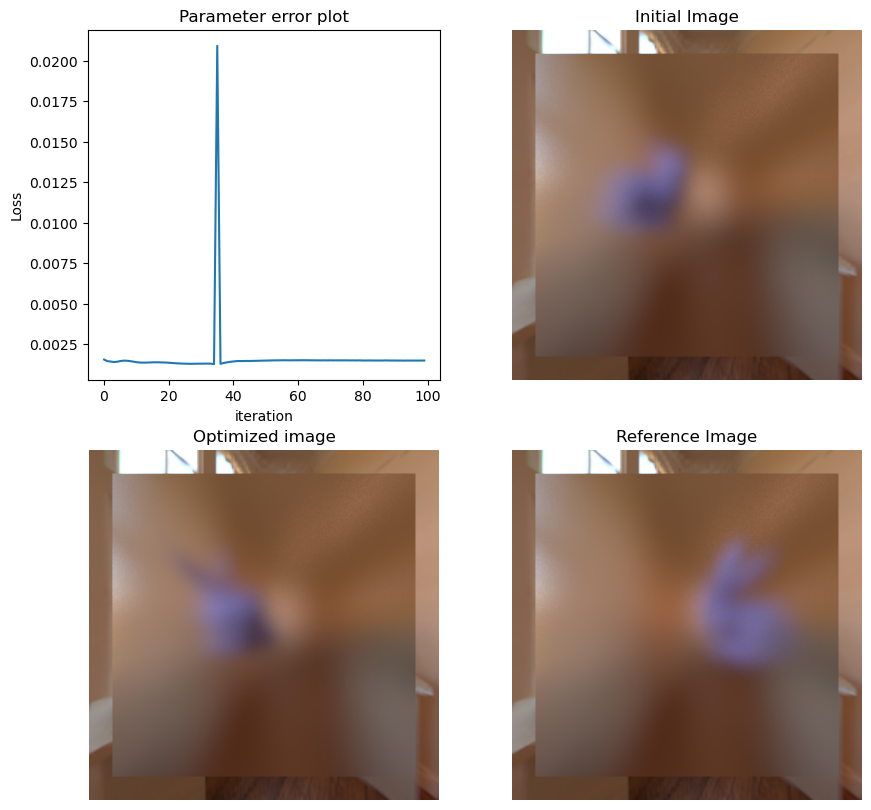

In [13]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

axs[0][0].plot(loss_hist)
axs[0][0].set_xlabel('iteration'); 
axs[0][0].set_ylabel('Loss'); 
axs[0][0].set_title('Parameter error plot');

axs[0][1].imshow(mi.util.convert_to_bitmap(img_init))
axs[0][1].axis('off')
axs[0][1].set_title('Initial Image')

final_img = mi.render(scene, spp=1024)
axs[1][0].imshow(mi.util.convert_to_bitmap(final_img))
axs[1][0].axis('off')
axs[1][0].set_title('Optimized image')

axs[1][1].imshow(mi.util.convert_to_bitmap(img_ref))
axs[1][1].axis('off')
axs[1][1].set_title('Reference Image');

In [14]:

mi.util.convert_to_bitmap(final_img).write('mse_img_final.png')

## 12. Method C: LOIR with finite-difference gradients

This method does not use analytic gradients through the renderer. Instead, it estimates gradients by finite differences using a handcrafted LOIR-style objective.


## LOIR optimization

This block uses the same pose parameterization, but optimizes against the multi-scale grayscale CDF loss used by `LOIR`. Since this notebook is Mitsuba-first, the optimization here follows the simpler finite-difference loop used elsewhere in the repo for non-AD objectives.


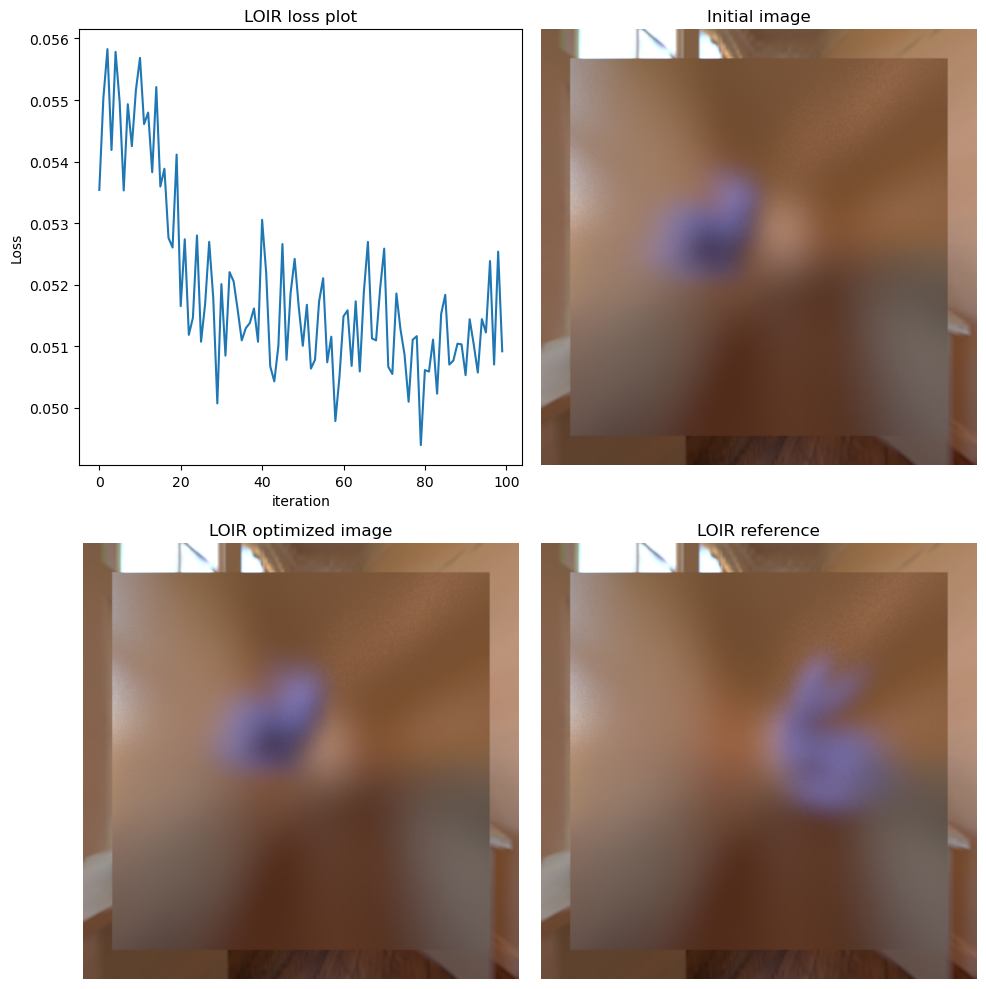

In [15]:
loir_iteration_count = iteration_count
loir_spp = spp
loir_lr = 0.05
loir_fd_eps = 0.01
# opt = mi.ad.Adam(lr=0.025)
# opt['angle'] = mi.Float(0.5)
# opt['trans'] = mi.Point2f(0.5, 0.0)
loir_pose = np.array([0.5, -0.8, 0.2], dtype=np.float64)  # angle, tx, ty
loir_state = {
    'm': np.zeros(3, dtype=np.float64),
    'v': np.zeros(3, dtype=np.float64),
    't': 0,
}

loir_loss_hist = []
for it in range(loir_iteration_count):
    loir_pose[0], loir_pose[1], loir_pose[2] = clip_pose(*loir_pose)
    pred_np, angle, tx, ty = render_pose_np(*loir_pose, seed=30_000 + it, spp=loir_spp)
    loss_value = loir_loss_np(pred_np, img_ref_np)

    grad = np.zeros(3, dtype=np.float64)
    for dim in range(3):
        step = np.zeros(3, dtype=np.float64)
        step[dim] = loir_fd_eps
        pred_p, *_ = render_pose_np(*(loir_pose + step), seed=31_000 + 2 * it + dim, spp=loir_spp)
        pred_m, *_ = render_pose_np(*(loir_pose - step), seed=32_000 + 2 * it + dim, spp=loir_spp)
        lp = loir_loss_np(pred_p, img_ref_np)
        lm = loir_loss_np(pred_m, img_ref_np)
        grad[dim] = (lp - lm) / (2.0 * loir_fd_eps)

    loir_pose = adam_update_vec(loir_pose, grad, loir_state, loir_lr)
    loir_pose[0], loir_pose[1], loir_pose[2] = clip_pose(*loir_pose)
    loir_loss_hist.append(loss_value)
    print(
        f"LOIR iter {it:02d}: error={loss_value:.6f}, angle={loir_pose[0]:.4f}, "
        f"trans=[{loir_pose[1]:.4f}, {loir_pose[2]:.4f}]",
        end='\r'
    )

loir_img_final, *_ = render_pose_tensor(*loir_pose, seed=40_000, spp=1024)
show_optimization_summary(loir_loss_hist, loir_img_final, img_ref, 'LOIR')


## 13. Method D: PRDPT

This method estimates a search direction by perturbing the pose and comparing symmetric samples around the current point.


## PRDPT optimization

This block uses a PRDPT-style smoothed objective: it samples antithetic perturbations around the current pose, estimates a smoothed gradient from the paired losses, and updates the three pose parameters with Adam.


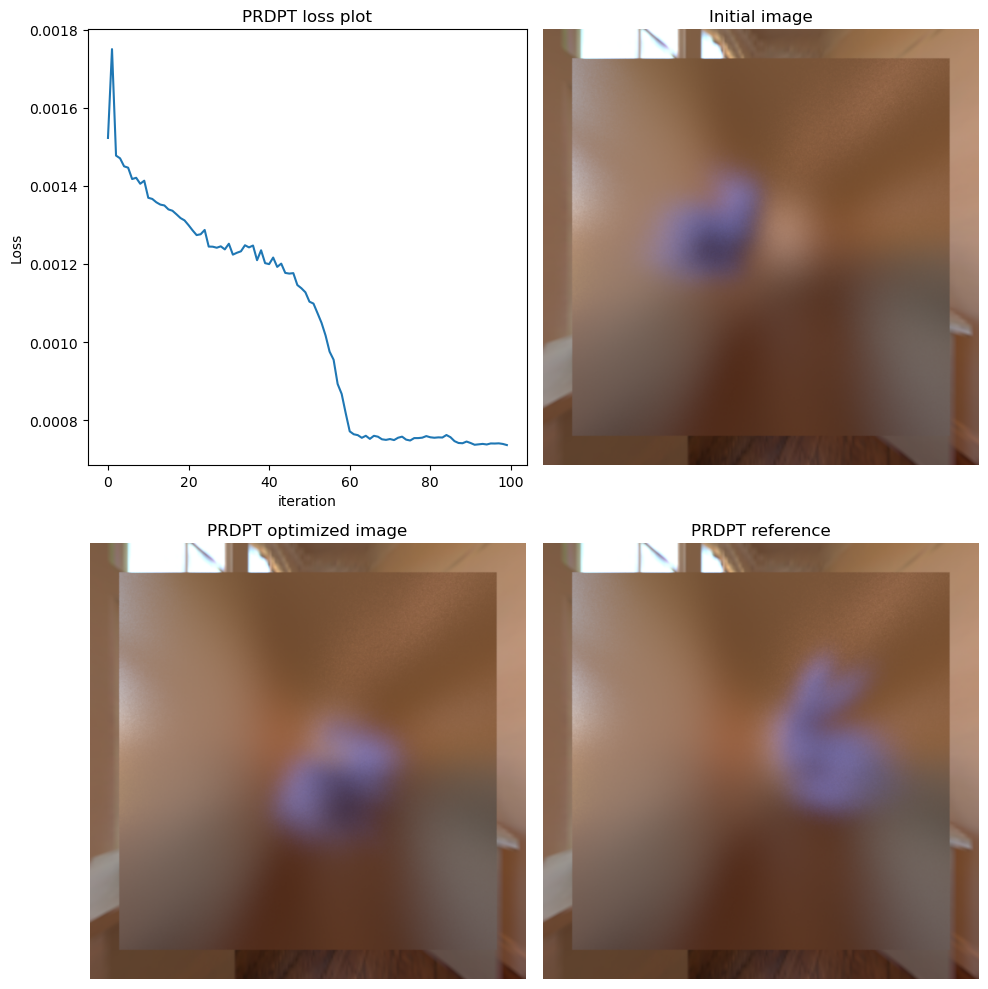

In [16]:
prdpt_iteration_count = iteration_count
prdpt_spp = spp
prdpt_lr = 0.05
prdpt_sigma = 0.1
prdpt_sigma_min = 0.01
prdpt_nsamples = 8
prdpt_pose = np.array([0.5, -0.8, 0.2], dtype=np.float64)  # angle, tx, ty
prdpt_state = {
    'm': np.zeros(3, dtype=np.float64),
    'v': np.zeros(3, dtype=np.float64),
    't': 0,
}

prdpt_loss_hist = []
for it in range(prdpt_iteration_count):
    frac = it / max(prdpt_iteration_count - 1, 1)
    sigma = max(prdpt_sigma_min, prdpt_sigma * (1.0 - frac) + prdpt_sigma_min * frac)
    grad_acc = np.zeros(3, dtype=np.float64)
    loss_acc = 0.0
    half = max(1, prdpt_nsamples // 2)

    for k in range(half):
        eps = sigma * np.random.randn(3)
        pred_p, *_ = render_pose_np(*(prdpt_pose + eps), seed=50_000 + 2 * k + 2 * half * it, spp=prdpt_spp)
        pred_m, *_ = render_pose_np(*(prdpt_pose - eps), seed=50_001 + 2 * k + 2 * half * it, spp=prdpt_spp)
        lp = float(np.mean((pred_p - img_ref_np) ** 2))
        lm = float(np.mean((pred_m - img_ref_np) ** 2))
        grad_acc += ((lp - lm) / (2.0 * sigma)) * (eps / sigma)
        loss_acc += 0.5 * (lp + lm)

    grad = grad_acc / half
    loss_value = loss_acc / half
    prdpt_pose = adam_update_vec(prdpt_pose, grad, prdpt_state, prdpt_lr)
    prdpt_pose[0], prdpt_pose[1], prdpt_pose[2] = clip_pose(*prdpt_pose)
    prdpt_loss_hist.append(loss_value)
    print(
        f"PRDPT iter {it:02d}: error={loss_value:.6f}, sigma={sigma:.4f}, angle={prdpt_pose[0]:.4f}, "
        f"trans=[{prdpt_pose[1]:.4f}, {prdpt_pose[2]:.4f}]",
        end='\r'
    )

prdpt_img_final, *_ = render_pose_tensor(*prdpt_pose, seed=60_000, spp=1024)
show_optimization_summary(prdpt_loss_hist, prdpt_img_final, img_ref, 'PRDPT')


## 14. Notes

Because the code cells are reused directly from `test.ipynb`, this notebook should stay behaviorally aligned with the source notebook while being easier to read top-to-bottom.
